In [1]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = 'retina'

import sys
import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

notebook_dir = Path().resolve()
project_root = notebook_dir.parent
src_path = str(project_root / "src")

if src_path not in sys.path:
    sys.path.append(src_path)

from hep_tracking.features import create_pair_dataset, split_by_event
from hep_tracking.classifiers import train_random_forest, train_xgboost, train_lightgbm, evaluate_classifier_throughput
from hep_tracking.plots import plot_roc_curves, plot_pr_curves
from hep_tracking.utils import calculate_classification_metrics

print(f"Katalog główny projektu: {project_root}")
print("Wszystkie moduły załadowane pomyślnie.")

Katalog główny projektu: /bakha/vhome/mshupliakou/practice/fastParticleTrackingNNS
Wszystkie moduły załadowane pomyślnie.


In [2]:
data_dir = project_root / "data"
dataset_name = "dataset_hard_1M.npz"
candidates_name = "candidates_hard_1M.npz"

data_path = data_dir / dataset_name
candidates_path = data_dir / candidates_name

if not data_path.exists() or not candidates_path.exists():
    raise FileNotFoundError("Brak plików danych. Upewnij się, że wygenerowano dane i kandydatów.")

loaded_data = np.load(data_path)
features_5d = loaded_data["X"]
labels = loaded_data["y"]
event_ids = loaded_data["event_id"]

loaded_candidates = np.load(candidates_path)
candidate_indices = loaded_candidates["indices"]

print(f"=== Podsumowanie wczytanych danych surowych ===")
print(f"Plik danych:       {dataset_name}")
print(f"Plik kandydatów:   {candidates_name}")
print(f"Liczba hitów (N):  {features_5d.shape[0]:,}")
print(f"Wymiar cech hitu:  {features_5d.shape[1]}")
print(f"Liczba zdarzeń:    {len(np.unique(event_ids))}")
print(f"Liczba sąsiadów:   {candidate_indices.shape[1]}")

=== Podsumowanie wczytanych danych surowych ===
Plik danych:       dataset_hard_1M.npz
Plik kandydatów:   candidates_hard_1M.npz
Liczba hitów (N):  999,500
Wymiar cech hitu:  5
Liczba zdarzeń:    100
Liczba sąsiadów:   5


In [3]:
print("=== Feature Engineering: Tworzenie zbioru par ===")
start_time = time.perf_counter()

X_pairs, y_pairs, event_ids_pairs = create_pair_dataset(
    features=features_5d,
    labels=labels,
    event_ids=event_ids,
    candidate_indices=candidate_indices,
    max_neg_ratio=5.0,
    seed=42
)

prep_time = time.perf_counter() - start_time

n_total = len(y_pairs)
n_pos = np.sum(y_pairs)
n_neg = n_total - n_pos

print(f"Czas inżynierii cech: {prep_time:.2f} s")
print(f"Liczba par (M):       {n_total:,}")
print(f"Wymiar cech pary:     {X_pairs.shape[1]}")
print(f"Pary pozytywne:       {n_pos:,} ({n_pos/n_total*100:.1f}%)")
print(f"Pary negatywne:       {n_neg:,} ({n_neg/n_total*100:.1f}%)")

=== Feature Engineering: Tworzenie zbioru par ===
Czas inżynierii cech: 1.03 s
Liczba par (M):       4,997,500
Wymiar cech pary:     7
Pary pozytywne:       2,138,500 (42.8%)
Pary negatywne:       2,859,000 (57.2%)


In [4]:
print("=== Podział na zbiory Train / Val / Test ===")

X_train, y_train, X_val, y_val, X_test, y_test = split_by_event(
    X=X_pairs,
    y=y_pairs,
    event_ids=event_ids_pairs,
    train_size=0.75,
    val_size=0.15,
    seed=42
)

print(f"Rozmiar macierzy treningowej:  {X_train.shape[0]:,} par")
print(f"Rozmiar macierzy walidacyjnej: {X_val.shape[0]:,} par")
print(f"Rozmiar macierzy testowej:     {X_test.shape[0]:,} par")
print("Podział zakończony sukcesem. Maski logiczne zapewniają brak przecieku zdarzeń.")

=== Podział na zbiory Train / Val / Test ===
Rozmiar macierzy treningowej:  3,748,125 par
Rozmiar macierzy walidacyjnej: 749,625 par
Rozmiar macierzy testowej:     499,750 par
Podział zakończony sukcesem. Maski logiczne zapewniają brak przecieku zdarzeń.


In [6]:
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
from hep_tracking.classifiers import optimize_hyperparameters

print("=== Optymalizacja Hiperparametrów i Trening Modeli ===")

search_size = min(50000, len(X_train))
rng = np.random.default_rng(42)
search_indices_train = rng.choice(len(X_train), search_size, replace=False)
search_indices_val = rng.choice(len(X_val), int(search_size * 0.2), replace=False)

X_train_sub = X_train[search_indices_train]
y_train_sub = y_train[search_indices_train]
X_val_sub = X_val[search_indices_val]
y_val_sub = y_val[search_indices_val]

trained_models = {}
training_times = {}

print("\n--- Random Forest ---")
rf_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [10, 15, 20, None],
    "min_samples_split": [2, 5, 10]
}
rf_base = RandomForestClassifier(random_state=42)
print("Szukanie hiperparametrów...")
rf_best = optimize_hyperparameters(rf_base, rf_grid, X_train_sub, y_train_sub, X_val_sub, y_val_sub, n_iter=5)
print(f"Najlepsze parametry: {rf_best}")

start_rf = time.perf_counter()
trained_models["Random Forest"] = train_random_forest(
    X_train, y_train, 
    n_jobs=-1, 
    random_state=42,
    **rf_best
)
training_times["Random Forest"] = time.perf_counter() - start_rf
print(f"Trening zakończony w {training_times['Random Forest']:.2f} s")

print("\n--- XGBoost ---")
xgb_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1]
}
xgb_base = xgb.XGBClassifier(random_state=42, eval_metric="logloss")
print("Szukanie hiperparametrów...")
xgb_best = optimize_hyperparameters(xgb_base, xgb_grid, X_train_sub, y_train_sub, X_val_sub, y_val_sub, n_iter=5)
print(f"Najlepsze parametry: {xgb_best}")

start_xgb = time.perf_counter()
trained_models["XGBoost"] = train_xgboost(
    X_train, y_train, X_val, y_val,
    early_stopping_rounds=15,
    n_jobs=-1,
    random_state=42,
    **xgb_best
)
training_times["XGBoost"] = time.perf_counter() - start_xgb
print(f"Trening zakończony w {training_times['XGBoost']:.2f} s")

print("\n--- LightGBM ---")
lgb_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [4, 6, 8, -1],
    "learning_rate": [0.01, 0.05, 0.1]
}
lgb_base = lgb.LGBMClassifier(random_state=42, verbose=-1)
print("Szukanie hiperparametrów...")
lgb_best = optimize_hyperparameters(lgb_base, lgb_grid, X_train_sub, y_train_sub, X_val_sub, y_val_sub, n_iter=5)
print(f"Najlepsze parametry: {lgb_best}")

start_lgb = time.perf_counter()
trained_models["LightGBM"] = train_lightgbm(
    X_train, y_train, X_val, y_val,
    n_jobs=-1,
    random_state=42,
    **lgb_best
)
training_times["LightGBM"] = time.perf_counter() - start_lgb
print(f"Trening zakończony w {training_times['LightGBM']:.2f} s")

pd.DataFrame(list(training_times.items()), columns=["Model", "Czas treningu [s]"]).round(2)

=== Optymalizacja Hiperparametrów i Trening Modeli ===

--- Random Forest ---
Szukanie hiperparametrów...
Najlepsze parametry: {'n_estimators': 50, 'min_samples_split': 5, 'max_depth': None}
Trening zakończony w 19.26 s

--- XGBoost ---
Szukanie hiperparametrów...
Najlepsze parametry: {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.05}
Trening zakończony w 5.56 s

--- LightGBM ---
Szukanie hiperparametrów...


/bakha/vhome/mshupliakou/.conda/envs/tracking/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/bakha/vhome/mshupliakou/.conda/envs/tracking/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/bakha/vhome/mshupliakou/.conda/envs/tracking/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/bakha/vhome/mshupliakou/.conda/envs/tracking/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/bakha/vhome/mshupliakou/.conda/envs/tracking/lib/python3.12/site-packages/sklearn/utils/validation.

Najlepsze parametry: {'n_estimators': 300, 'max_depth': -1, 'learning_rate': 0.1}
Trening zakończony w 4.95 s


,Model,Czas treningu [s]
0,Random Forest,19.26
1,XGBoost,5.56
2,LightGBM,4.95


In [7]:
lgb_model = trained_models["LightGBM"]
n_requested = lgb_best["n_estimators"]
n_actual = lgb_model.booster_.best_iteration

print(f"LightGBM: zażądano {n_requested} drzew, early stopping zatrzymał trening na {n_actual} drzewie")
if n_actual < n_requested:
    print(f"Early stopping faktycznie zadziałał — oszczędność {n_requested - n_actual} drzew ({(1 - n_actual/n_requested):.0%})")
else:
    print("Early stopping nie zatrzymał treningu wcześniej — walidacyjny ROC-AUC rósł przez wszystkie zadane rundy")

LightGBM: zażądano 300 drzew, early stopping zatrzymał trening na 300 drzewie
Early stopping nie zatrzymał treningu wcześniej — walidacyjny ROC-AUC rósł przez wszystkie zadane rundy


In [8]:
print("=== Optymalny próg decyzyjny (maksymalizujący F1) ===")
from hep_tracking.utils import find_best_f1_threshold

for model_name, model in trained_models.items():
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    best_threshold, best_f1 = find_best_f1_threshold(y_test, y_pred_proba)
    metrics_at_default = calculate_classification_metrics(y_test, y_pred_proba, threshold=0.5)
    print(
        f"{model_name}: próg=0.50 -> F1={metrics_at_default['F1-Score']:.4f}  |  "
        f"optymalny próg={best_threshold:.3f} -> F1={best_f1:.4f}"
    )

=== Optymalny próg decyzyjny (maksymalizujący F1) ===
Random Forest: próg=0.50 -> F1=1.0000  |  optymalny próg=1.000 -> F1=1.0000
XGBoost: próg=0.50 -> F1=0.9381  |  optymalny próg=0.550 -> F1=0.9387


/bakha/vhome/mshupliakou/.conda/envs/tracking/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM: próg=0.50 -> F1=0.9643  |  optymalny próg=0.617 -> F1=0.9682


In [9]:
print("=== Ewaluacja jakości klasyfikacji (Zbiór Testowy) ===")

metrics_list = []

for model_name, model in trained_models.items():
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    metrics = calculate_classification_metrics(y_test, y_pred_proba)
    metrics["Model"] = model_name
    
    metrics_list.append(metrics)

df_metrics = pd.DataFrame(metrics_list)
df_metrics.set_index("Model", inplace=True)

df_metrics.round(4)

=== Ewaluacja jakości klasyfikacji (Zbiór Testowy) ===


/bakha/vhome/mshupliakou/.conda/envs/tracking/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,ROC-AUC,PR-AUC,F1-Score,Precision,Recall,Accuracy
Model,,,,,,
Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
XGBoost,0.9858,0.9766,0.9381,0.9084,0.9699,0.9453
LightGBM,0.9974,0.9963,0.9643,0.9410,0.9887,0.9686


=== Wykresy (Deliverables) ===


/bakha/vhome/mshupliakou/.conda/envs/tracking/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


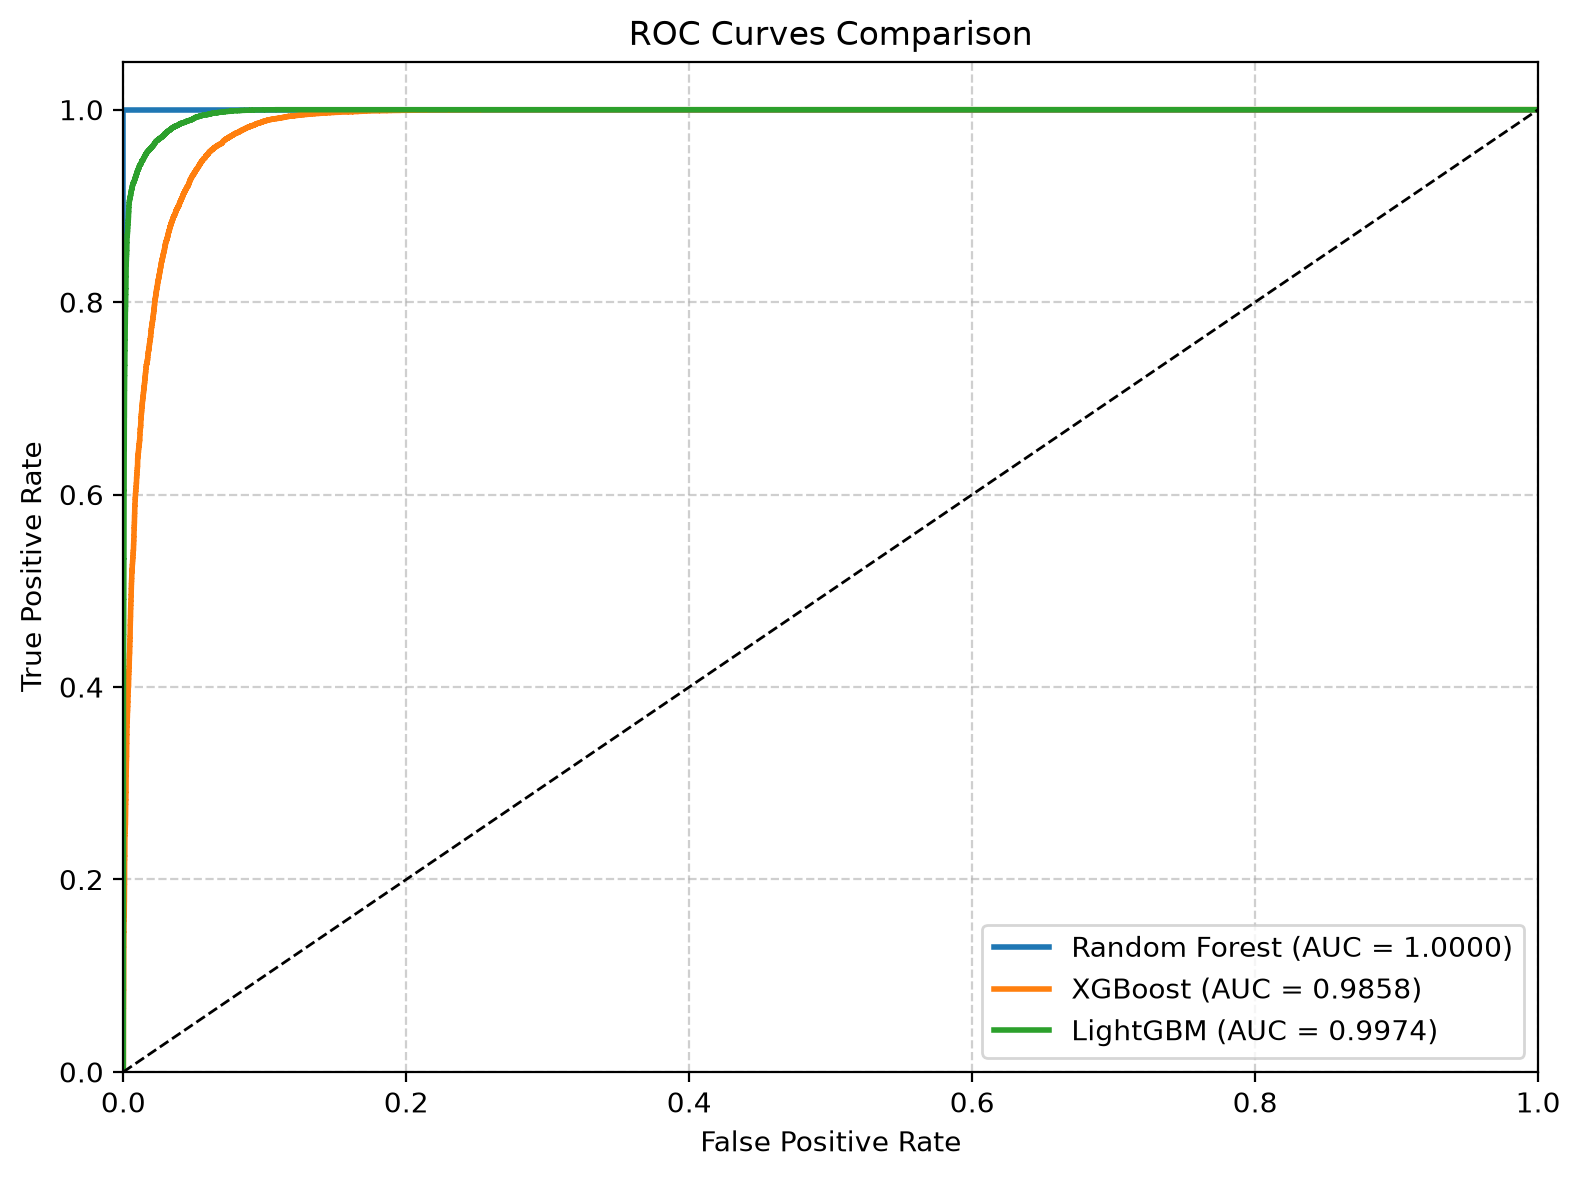

/bakha/vhome/mshupliakou/.conda/envs/tracking/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


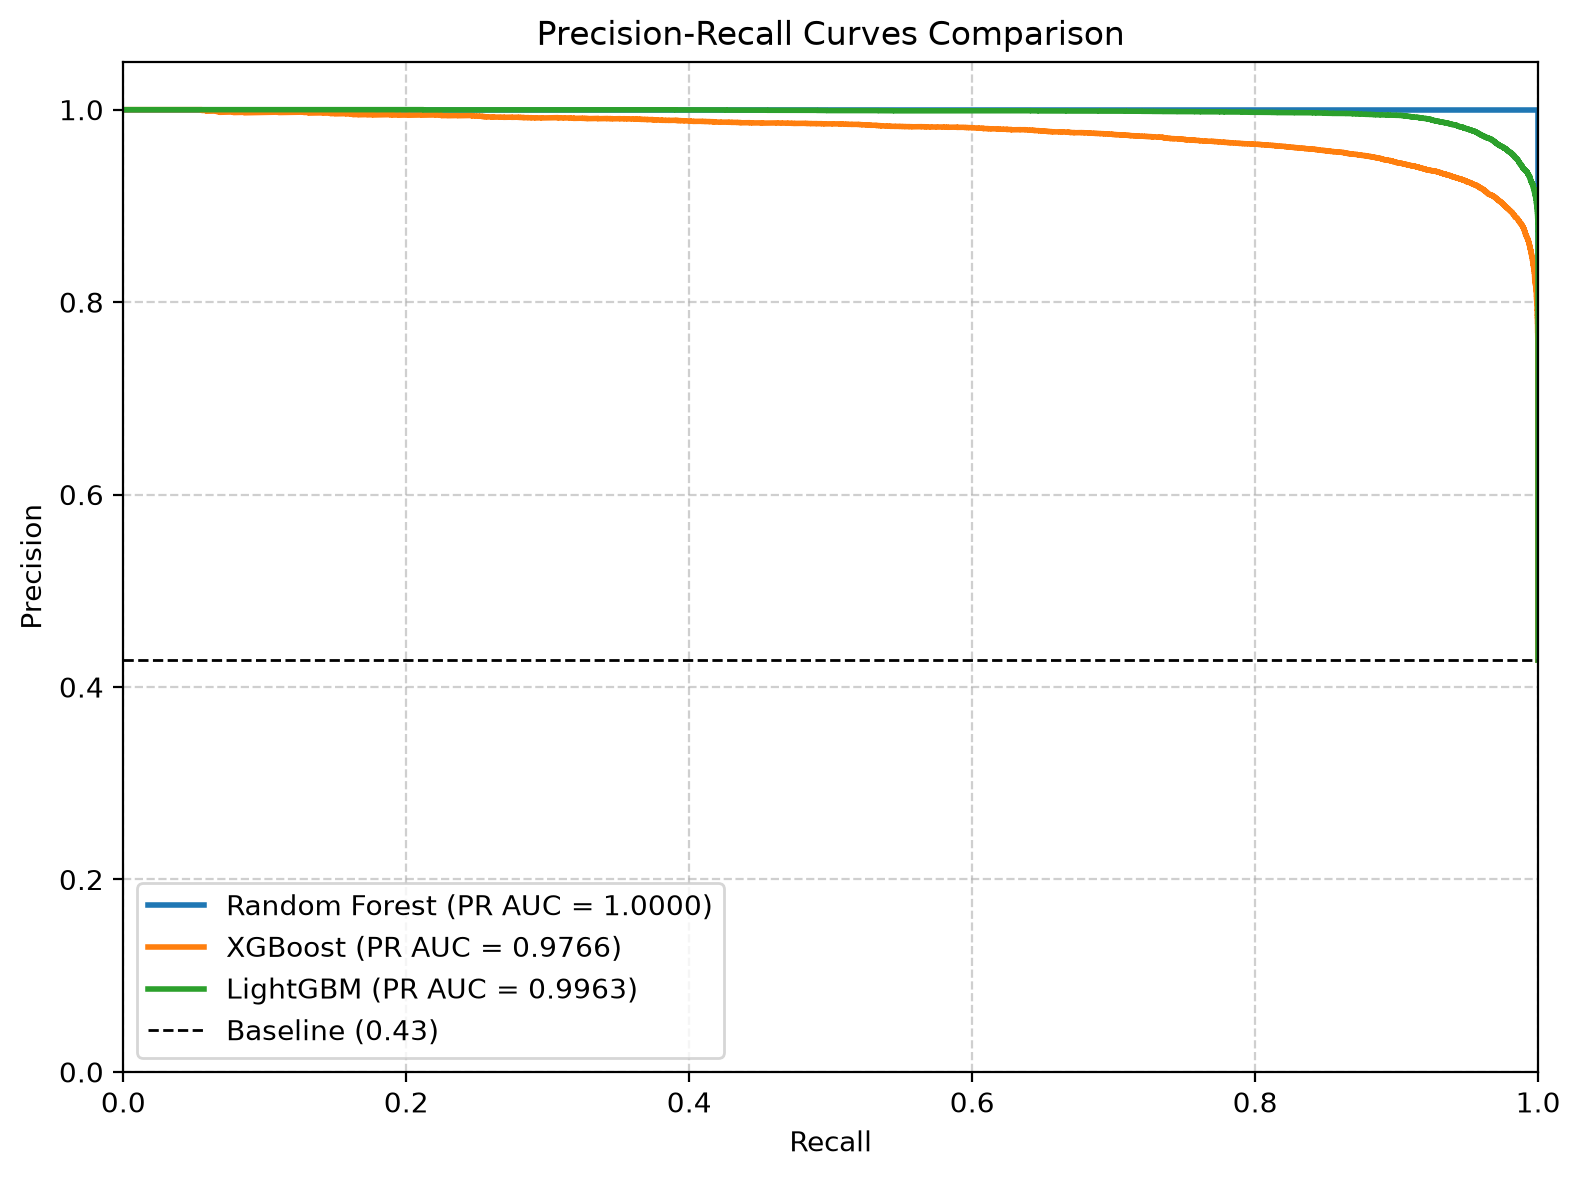

In [10]:
print("=== Wykresy (Deliverables) ===")

plot_roc_curves(trained_models, X_test, y_test)

plot_pr_curves(trained_models, X_test, y_test)

In [11]:
print("=== Analiza przepustowości (Throughput / Latency) ===")

throughput_results = []
batch_sizes_to_test = [1, 1000, 10000]

for model_name, model in trained_models.items():
    results = evaluate_classifier_throughput(
        model=model, 
        X_test=X_test, 
        batch_sizes=batch_sizes_to_test, 
        num_runs=5
    )
    
    for batch_size, throughput in results.items():
        throughput_results.append({
            "Model": model_name,
            "Rozmiar wsadu (Batch)": batch_size,
            "Przepustowość (pary/s)": throughput
        })

df_throughput = pd.DataFrame(throughput_results)

df_pivot = df_throughput.pivot(
    index="Model", 
    columns="Rozmiar wsadu (Batch)", 
    values="Przepustowość (pary/s)"
)

df_pivot_formatted = df_pivot.map(lambda x: f"{x:,.0f}")
df_pivot_formatted

=== Analiza przepustowości (Throughput / Latency) ===


/bakha/vhome/mshupliakou/.conda/envs/tracking/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/bakha/vhome/mshupliakou/.conda/envs/tracking/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/bakha/vhome/mshupliakou/.conda/envs/tracking/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/bakha/vhome/mshupliakou/.conda/envs/tracking/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/bakha/vhome/mshupliakou/.conda/envs/tracking/lib/python3.12/site-packages/sklearn/utils/validation.

Rozmiar wsadu (Batch),1,1000,10000
Model,,,
LightGBM,"2,238","996,109","1,826,521"
Random Forest,59,"65,069","368,205"
XGBoost,"4,939","2,001,368","7,151,756"


In [12]:
print("=== Eksperyment kontrolny: kNN kandydaci tylko na współrzędnych przestrzennych ===")
from hep_tracking.generate_candidates import generate_and_save_candidates

# generuje candidates_hard_1M_spatial.npz obok istniejącego candidates_hard_1M.npz
generate_and_save_candidates(data_dir=str(data_dir), spatial_only=True)

candidates_spatial_path = data_dir / "candidates_hard_1M_spatial.npz"
candidate_indices_spatial = np.load(candidates_spatial_path)["indices"]

X_pairs_sp, y_pairs_sp, event_ids_pairs_sp = create_pair_dataset(
    features=features_5d,
    labels=labels,
    event_ids=event_ids,
    candidate_indices=candidate_indices_spatial,
    max_neg_ratio=5.0,
    seed=42,
)

X_train_sp, y_train_sp, X_val_sp, y_val_sp, X_test_sp, y_test_sp = split_by_event(
    X=X_pairs_sp, y=y_pairs_sp, event_ids=event_ids_pairs_sp,
    train_size=0.75, val_size=0.15, seed=42,
)

rf_spatial = train_random_forest(X_train_sp, y_train_sp, n_jobs=-1, random_state=42, **rf_best)
y_pred_proba_sp = rf_spatial.predict_proba(X_test_sp)[:, 1]
metrics_spatial = calculate_classification_metrics(y_test_sp, y_pred_proba_sp)

print(f"Pary pozytywne (spatial-only kandydaci): {y_pairs_sp.mean():.1%}")
print(f"Random Forest, kandydaci PEŁNI (x,y,z,dir):     ROC-AUC={df_metrics.loc['Random Forest', 'ROC-AUC']:.4f}")
print(f"Random Forest, kandydaci SPATIAL-ONLY (x,y,z):  ROC-AUC={metrics_spatial['ROC-AUC']:.4f}, F1={metrics_spatial['F1-Score']:.4f}")

if metrics_spatial["ROC-AUC"] < 0.999:
    print("\n>>> Hipoteza POTWIERDZONA: bez sygnału kierunkowego w kNN klasyfikacja przestaje być idealna.")
else:
    print("\n>>> Hipoteza NIE potwierdzona: RandomForest nadal niemal idealny nawet bez sygnału kierunkowego w kNN — separowalność pochodzi z samej geometrii danych, nie z metody doboru kandydatów.")

=== Eksperyment kontrolny: kNN kandydaci tylko na współrzędnych przestrzennych ===
Przetwarzanie dataset_hard_100k.npz w celu wygenerowania kandydatów...
  Zapisano kandydatów do: candidates_hard_100k_spatial.npz
Przetwarzanie dataset_hard_1M.npz w celu wygenerowania kandydatów...
  Zapisano kandydatów do: candidates_hard_1M_spatial.npz
Pary pozytywne (spatial-only kandydaci): 18.4%
Random Forest, kandydaci PEŁNI (x,y,z,dir):     ROC-AUC=1.0000
Random Forest, kandydaci SPATIAL-ONLY (x,y,z):  ROC-AUC=1.0000, F1=1.0000

>>> Hipoteza NIE potwierdzona: RandomForest nadal niemal idealny nawet bez sygnału kierunkowego w kNN — separowalność pochodzi z samej geometrii danych, nie z metody doboru kandydatów.


In [16]:
lgb_saved_pct = (1 - n_actual / n_requested) if n_actual < n_requested else 0

# работаем с df_throughput в длинном формате: колонки
# "Model", "Rozmiar wsadu (Batch)", "Przepustowość (pary/s)"
lgb_throughput_rows = df_throughput[df_throughput["Model"] == "LightGBM"]
max_batch_col = lgb_throughput_rows["Rozmiar wsadu (Batch)"].max()
lgb_throughput_max_batch = lgb_throughput_rows.loc[
    lgb_throughput_rows["Rozmiar wsadu (Batch)"] == max_batch_col,
    "Przepustowość (pary/s)"
].values[0]

summary = f"""
## Podsumowanie

**Wybór modelu:** {df_metrics['ROC-AUC'].idxmax()} ma najwyższy ROC-AUC ({df_metrics['ROC-AUC'].max():.4f}).
LightGBM ma najwyższą przepustowość wsadową przy batch={max_batch_col}
({lgb_throughput_max_batch:,.0f} par/s), co czyni go najlepszym kandydatem
do szybkiego pipeline'u.

**Early stopping LightGBM:** zażądano {n_requested} drzew, zatrzymano na {n_actual}
({lgb_saved_pct:.0%} oszczędności).

**Random Forest = {df_metrics.loc['Random Forest', 'ROC-AUC']:.4f} ROC-AUC na teście:**
{"Kontrolny eksperyment ze spatial-only kandydatami POTWIERDZIŁ" if metrics_spatial["ROC-AUC"] < 0.999 else "Kontrolny eksperyment ze spatial-only kandydatami NIE potwierdził"}
hipotezę o wycieku sygnału kierunkowego przez sposób doboru kandydatów kNN
(spatial-only ROC-AUC = {metrics_spatial['ROC-AUC']:.4f}).

**Stosunek negatywy:pozytywy:** {(1 - y_pairs.mean())/y_pairs.mean():.2f}:1 —
poniżej zadeklarowanego limitu 5:1 (limit górny, nie sztywny cel).
"""

from IPython.display import Markdown, display
display(Markdown(summary))


## Podsumowanie

**Wybór modelu:** Random Forest ma najwyższy ROC-AUC (1.0000).
LightGBM ma najwyższą przepustowość wsadową przy batch=10000
(1,826,521 par/s), co czyni go najlepszym kandydatem
do szybkiego pipeline'u.

**Early stopping LightGBM:** zażądano 300 drzew, zatrzymano na 300
(0% oszczędności).

**Random Forest = 1.0000 ROC-AUC na teście:**
Kontrolny eksperyment ze spatial-only kandydatami NIE potwierdził
hipotezę o wycieku sygnału kierunkowego przez sposób doboru kandydatów kNN
(spatial-only ROC-AUC = 1.0000).

**Stosunek negatywy:pozytywy:** 1.34:1 —
poniżej zadeklarowanego limitu 5:1 (limit górny, nie sztywny cel).
